# Fase 1 — Modelo predictivo
## Predicción de la variación mensual del IPC en Colombia por ciudad y grupo de gasto

**Proyecto integrador — Modelos y Simulación de Sistemas I — Universidad de Antioquia**

Este notebook cubre la Fase 1 del proyecto integrador:
1. Carga y descripción de los datos
2. Análisis exploratorio (EDA)
3. Ingeniería de variables (feature engineering)
4. Entrenamiento y comparación de modelos supervisados
5. Validación temporal (walk-forward) evitando fuga de información
6. Selección y guardado del mejor modelo

> **Nota sobre los datos:** este notebook usa `data/ipc_panel_sintetico.csv`,
> un panel **sintético** generado con `data/generar_datos.py`, calibrado con
> órdenes de magnitud realistas (ver comentarios en ese script) porque este
> entorno de desarrollo no tiene acceso a las APIs de DANE/Banrep. El
> pipeline completo (EDA → features → modelos → validación → guardado) está
> listo para recibir el dataset real sin modificaciones: basta con
> reemplazar el CSV de entrada por los datos reales, siguiendo las
> instrucciones al final de `data/generar_datos.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 4)
RANDOM_STATE = 42

## 1. Carga y descripción de los datos

In [2]:
df = pd.read_csv("data/ipc_panel_sintetico.csv", parse_dates=["fecha"])
print(f"Observaciones: {len(df):,}")
print(f"Ciudades: {df['ciudad'].nunique()}  |  Grupos de gasto: {df['grupo_gasto'].nunique()}")
print(f"Rango de fechas: {df['fecha'].min().date()} a {df['fecha'].max().date()}")
df.head()

Observaciones: 62,208
Ciudades: 24  |  Grupos de gasto: 12
Rango de fechas: 2008-01-01 a 2025-12-01


,fecha,ciudad,grupo_gasto,ipc_variacion_mensual,trm_promedio_mensual,tasa_banrep,petroleo_brent_usd
0,2008-01-01,Armenia,Alimentos y bebidas no alcohólicas,0.178,1960.62,9.50,89.29
1,2008-02-01,Armenia,Alimentos y bebidas no alcohólicas,0.990,1968.09,9.50,104.16
2,2008-03-01,Armenia,Alimentos y bebidas no alcohólicas,0.074,1981.01,9.50,104.04
3,2008-04-01,Armenia,Alimentos y bebidas no alcohólicas,0.406,2084.72,9.50,111.19
4,2008-05-01,Armenia,Alimentos y bebidas no alcohólicas,0.429,2167.14,9.75,109.93


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
fecha,62208,NaN,NaN,NaN,2016-12-15 17:33:20,2008-01-01 00:00:00,2012-06-23 12:00:00,2016-12-16 12:00:00,2021-06-08 12:00:00,2025-12-01 00:00:00,NaN
ciudad,62208,24,Armenia,2592,NaN,NaN,NaN,NaN,NaN,NaN,NaN
grupo_gasto,62208,12,Alimentos y bebidas no alcohólicas,5184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ipc_variacion_mensual,62208.0,NaN,NaN,NaN,0.49826,-3.5,0.226,0.49,0.762,6.0,0.527781
trm_promedio_mensual,62208.0,NaN,NaN,NaN,2869.855787,1783.47,2155.6825,3156.345,3417.0375,3910.32,665.308854
tasa_banrep,62208.0,NaN,NaN,NaN,11.229167,9.5,10.75,11.25,12.0,12.75,0.853326
petroleo_brent_usd,62208.0,NaN,NaN,NaN,65.702778,20.0,55.1725,63.32,76.02,111.67,18.417275


In [4]:
# Verificación de requisitos mínimos del proyecto integrador
assert len(df) >= 1000, "Se requieren al menos 1.000 observaciones"
n_predictoras = df.shape[1] - 1  # todas menos la variable objetivo
print(f"Observaciones: {len(df):,} (>= 1.000 requerido: {len(df) >= 1000})")
print(f"Columnas disponibles para features: {list(df.columns.drop('ipc_variacion_mensual'))}")

Observaciones: 62,208 (>= 1.000 requerido: True)
Columnas disponibles para features: ['fecha', 'ciudad', 'grupo_gasto', 'trm_promedio_mensual', 'tasa_banrep', 'petroleo_brent_usd']


## 2. Análisis exploratorio (EDA)

Revisamos la distribución de la variable objetivo, su evolución en el tiempo,
diferencias entre grupos de gasto y ciudades, y la relación con las
variables macro exógenas.

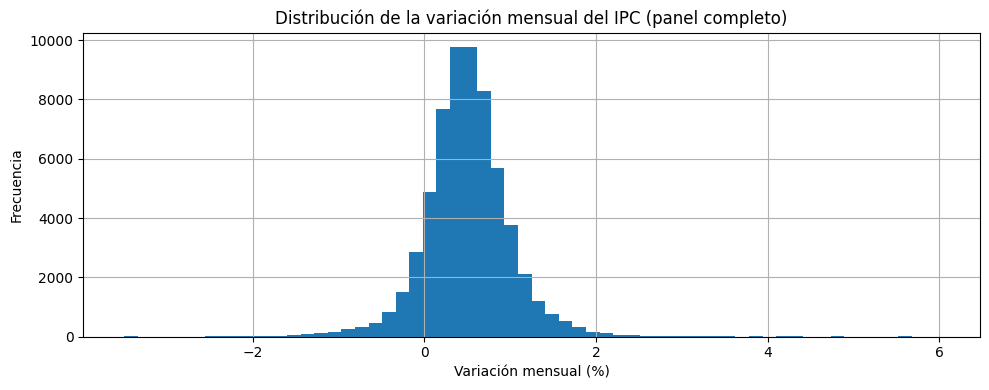

In [5]:
fig, ax = plt.subplots()
df["ipc_variacion_mensual"].hist(bins=60, ax=ax)
ax.set_title("Distribución de la variación mensual del IPC (panel completo)")
ax.set_xlabel("Variación mensual (%)")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("eda_distribucion.png", dpi=110)
plt.show()

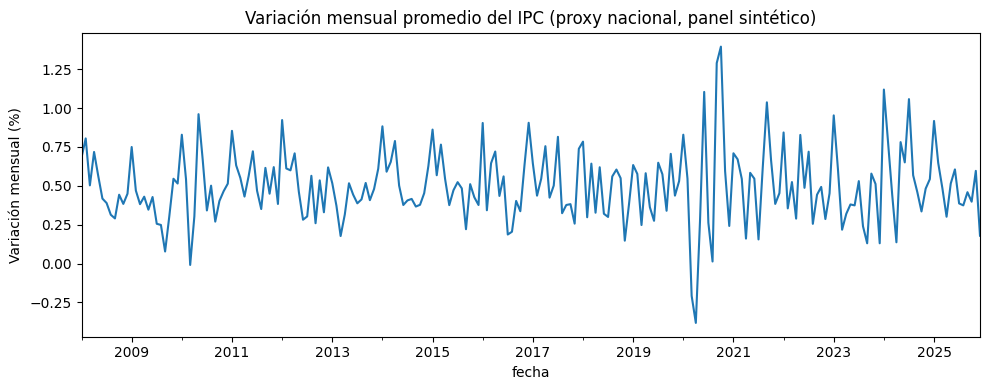

In [6]:
serie_nacional = df.groupby("fecha")["ipc_variacion_mensual"].mean()
fig, ax = plt.subplots()
serie_nacional.plot(ax=ax)
ax.set_title("Variación mensual promedio del IPC (proxy nacional, panel sintético)")
ax.set_ylabel("Variación mensual (%)")
plt.tight_layout()
plt.savefig("eda_serie_nacional.png", dpi=110)
plt.show()

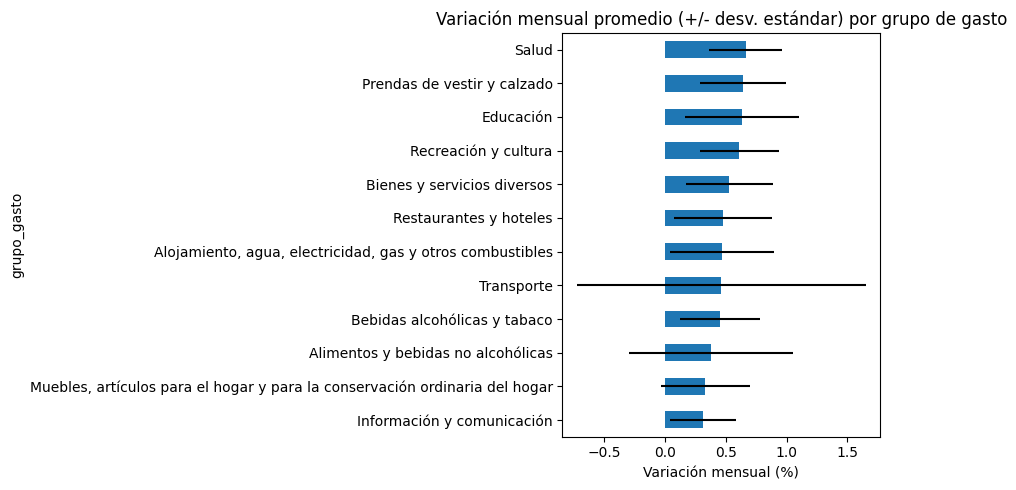

,mean,std
grupo_gasto,,
Información y comunicación,0.313958,0.267976
"Muebles, artículos para el hogar y para la conservación ordinaria del hogar",0.333322,0.366298
Alimentos y bebidas no alcohólicas,0.380822,0.672761
Bebidas alcohólicas y tabaco,0.451382,0.328914
Transporte,0.463397,1.185157
"Alojamiento, agua, electricidad, gas y otros combustibles",0.470580,0.423755
Restaurantes y hoteles,0.480800,0.403543
Bienes y servicios diversos,0.530404,0.360087
Recreación y cultura,0.612762,0.324399


In [7]:
promedio_por_grupo = df.groupby("grupo_gasto")["ipc_variacion_mensual"].agg(["mean", "std"]).sort_values("mean")
fig, ax = plt.subplots(figsize=(9, 5))
promedio_por_grupo["mean"].plot(kind="barh", xerr=promedio_por_grupo["std"], ax=ax)
ax.set_title("Variación mensual promedio (+/- desv. estándar) por grupo de gasto")
ax.set_xlabel("Variación mensual (%)")
plt.tight_layout()
plt.savefig("eda_por_grupo.png", dpi=110)
plt.show()
promedio_por_grupo

In [8]:
# Relación con variables macro exógenas (a nivel de serie nacional promedio)
macro_nacional = df.groupby("fecha")[["ipc_variacion_mensual", "trm_promedio_mensual",
                                       "tasa_banrep", "petroleo_brent_usd"]].mean()
macro_nacional[["trm_promedio_mensual", "tasa_banrep", "petroleo_brent_usd"]] \
    .corrwith(macro_nacional["ipc_variacion_mensual"]) \
    .rename("correlación con IPC (nivel de las variables)")

trm_promedio_mensual    0.031971
tasa_banrep             0.037971
petroleo_brent_usd      0.121500
Name: correlación con IPC (nivel de las variables), dtype: float64

**Lectura del EDA:** la variación mensual del IPC tiene una distribución
concentrada alrededor de un valor positivo pequeño con cola derecha (meses
de choques de precios). Hay diferencias claras entre grupos de gasto
(alimentos y transporte más volátiles, educación con estacionalidad marcada
en enero-febrero). Esto justifica incluir `ciudad`, `grupo_gasto` y variables
de estacionalidad como predictoras, además de las variables macro.

## 3. Ingeniería de variables (feature engineering)

Construimos:
- **Rezagos** de la propia serie IPC (ciudad, grupo_gasto) en t-1, t-3 y t-6
- **Estacionalidad** cíclica del mes (seno/coseno) en vez de un entero plano
- **Variación mensual** de TRM y petróleo (en vez de su nivel), más consistente económicamente
- **Codificación categórica** de `ciudad` y `grupo_gasto` (One-Hot)

In [9]:
panel = df.sort_values(["ciudad", "grupo_gasto", "fecha"]).copy()

grp = panel.groupby(["ciudad", "grupo_gasto"])["ipc_variacion_mensual"]
panel["ipc_lag1"] = grp.shift(1)
panel["ipc_lag3"] = grp.shift(3)
panel["ipc_lag6"] = grp.shift(6)

panel["mes"] = panel["fecha"].dt.month
panel["mes_sin"] = np.sin(2 * np.pi * panel["mes"] / 12)
panel["mes_cos"] = np.cos(2 * np.pi * panel["mes"] / 12)

panel["var_trm"] = panel.groupby(["ciudad", "grupo_gasto"])["trm_promedio_mensual"].pct_change() * 100
panel["var_petroleo"] = panel.groupby(["ciudad", "grupo_gasto"])["petroleo_brent_usd"].pct_change() * 100

# Eliminar filas iniciales sin rezago suficiente (primeros 6 meses de cada serie)
panel = panel.dropna(subset=["ipc_lag1", "ipc_lag3", "ipc_lag6", "var_trm", "var_petroleo"]).reset_index(drop=True)

feature_cols_num = ["ipc_lag1", "ipc_lag3", "ipc_lag6", "mes_sin", "mes_cos",
                     "tasa_banrep", "var_trm", "var_petroleo"]
feature_cols_cat = ["ciudad", "grupo_gasto"]
target_col = "ipc_variacion_mensual"

print(f"Observaciones tras feature engineering: {len(panel):,}")
panel[feature_cols_num + feature_cols_cat + [target_col]].head()

Observaciones tras feature engineering: 60,480


,ipc_lag1,ipc_lag3,ipc_lag6,mes_sin,mes_cos,tasa_banrep,var_trm,var_petroleo,ciudad,grupo_gasto,ipc_variacion_mensual
0,1.095,0.406,0.178,-0.500000,-8.660254e-01,9.75,-0.374328,-1.952181,Armenia,Alimentos y bebidas no alcohólicas,-0.772
1,-0.772,0.429,0.990,-0.866025,-5.000000e-01,9.75,-2.727016,-2.511645,Armenia,Alimentos y bebidas no alcohólicas,-0.837
2,-0.837,1.095,0.074,-1.000000,-1.836970e-16,9.75,-0.981383,-5.864718,Armenia,Alimentos y bebidas no alcohólicas,-1.173
3,-1.173,-0.772,0.406,-0.866025,5.000000e-01,9.75,0.830969,1.303742,Armenia,Alimentos y bebidas no alcohólicas,-0.501
4,-0.501,-0.837,0.429,-0.500000,8.660254e-01,9.75,2.611816,-6.336575,Armenia,Alimentos y bebidas no alcohólicas,-0.196


## 4. Validación temporal (walk-forward)

**No usamos una división aleatoria**, porque estamos ante series de tiempo:
mezclar meses futuros y pasados en train/test produciría fuga de información
(el modelo "vería el futuro"). En su lugar:

- **Entrenamiento:** enero 2008 – diciembre 2022
- **Prueba:** enero 2023 – diciembre 2025

Esto simula la situación real de producción: el modelo solo conoce el
pasado al momento de predecir.

In [10]:
fecha_corte = "2023-01-01"
train = panel[panel["fecha"] < fecha_corte]
test = panel[panel["fecha"] >= fecha_corte]

print(f"Train: {len(train):,} filas ({train['fecha'].min().date()} a {train['fecha'].max().date()})")
print(f"Test:  {len(test):,} filas ({test['fecha'].min().date()} a {test['fecha'].max().date()})")

X_train, y_train = train[feature_cols_num + feature_cols_cat], train[target_col]
X_test, y_test = test[feature_cols_num + feature_cols_cat], test[target_col]

Train: 50,112 filas (2008-07-01 a 2022-12-01)
Test:  10,368 filas (2023-01-01 a 2025-12-01)


## 5. Entrenamiento y comparación de modelos

Comparamos dos modelos:
- **Ridge Regression** — línea base lineal, rápida e interpretable
- **Random Forest** — captura no linealidades e interacciones entre ciudad/grupo/macro

Ambos dentro de un `Pipeline` con el mismo preprocesamiento (One-Hot para
las categóricas), para que el proceso sea reproducible y quede empaquetado
junto con el modelo.

In [11]:
preprocesador = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
    ],
    remainder="passthrough",
)

modelos = {
    "ridge": Pipeline([
        ("prep", preprocesador),
        ("reg", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ]),
    "random_forest": Pipeline([
        ("prep", preprocesador),
        ("reg", RandomForestRegressor(
            n_estimators=200, max_depth=12, min_samples_leaf=5,
            n_jobs=-1, random_state=RANDOM_STATE,
        )),
    ]),
}

resultados = []
predicciones = {}

for nombre, pipe in modelos.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    predicciones[nombre] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mape = np.mean(np.abs((y_test - y_pred) / y_test.replace(0, np.nan))) * 100

    resultados.append({"modelo": nombre, "MAE": mae, "RMSE": rmse, "MAPE_%": mape})

resultados_df = pd.DataFrame(resultados).sort_values("RMSE")
resultados_df

,modelo,MAE,RMSE,MAPE_%
1,random_forest,0.284434,0.378081,230.591613
0,ridge,0.319620,0.454294,216.306285


In [12]:
# Baseline ingenuo: predecir el mismo valor del mes anterior (persistencia)
y_naive = test["ipc_lag1"].values
mae_naive = mean_absolute_error(y_test, y_naive)
rmse_naive = mean_squared_error(y_test, y_naive) ** 0.5
print(f"Baseline ingenuo (persistencia t-1)  ->  MAE: {mae_naive:.3f}  RMSE: {rmse_naive:.3f}")
print("Los modelos deben superar este baseline para justificar su uso.")

Baseline ingenuo (persistencia t-1)  ->  MAE: 0.461  RMSE: 0.663
Los modelos deben superar este baseline para justificar su uso.


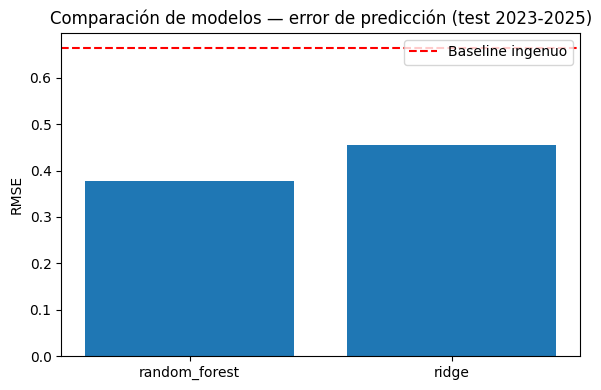

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(resultados_df["modelo"], resultados_df["RMSE"])
ax.axhline(rmse_naive, color="red", linestyle="--", label="Baseline ingenuo")
ax.set_ylabel("RMSE")
ax.set_title("Comparación de modelos — error de predicción (test 2023-2025)")
ax.legend()
plt.tight_layout()
plt.savefig("comparacion_modelos.png", dpi=110)
plt.show()

## 6. Importancia de variables (interpretación)

Para el mejor modelo, revisamos qué variables aportan más a la predicción —
esto conecta el resultado técnico con la interpretación macroeconómica
pedida en el proyecto (p. ej. si el rezago propio del IPC domina, o si TRM
y petróleo tienen peso relevante en grupos como Transporte).

Mejor modelo según RMSE en test: random_forest


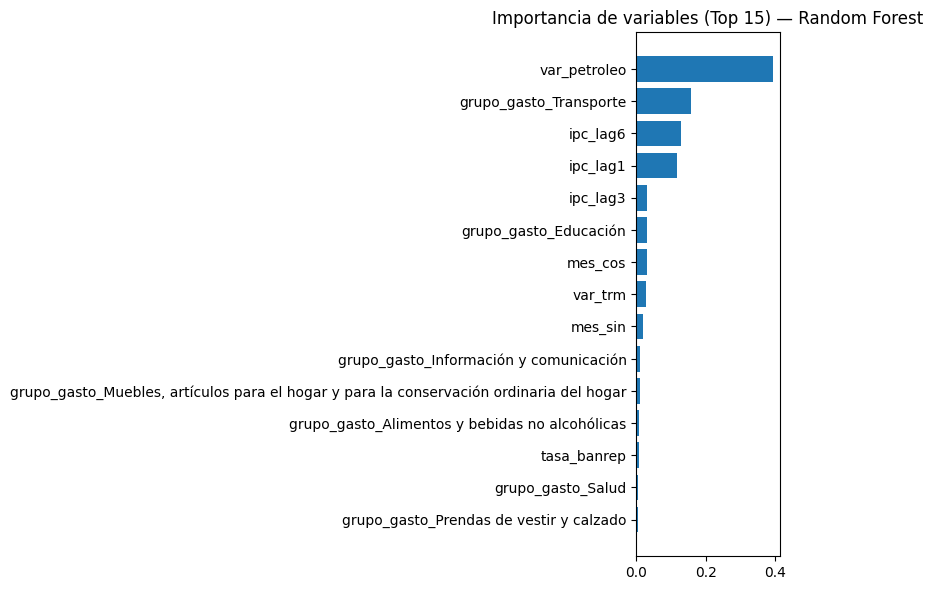

In [14]:
mejor_nombre = resultados_df.iloc[0]["modelo"]
mejor_pipe = modelos[mejor_nombre]
print(f"Mejor modelo según RMSE en test: {mejor_nombre}")

if mejor_nombre == "random_forest":
    ohe = mejor_pipe.named_steps["prep"].named_transformers_["cat"]
    nombres_cat = list(ohe.get_feature_names_out(feature_cols_cat))
    nombres_features = nombres_cat + feature_cols_num
    importancias = mejor_pipe.named_steps["reg"].feature_importances_
    imp_df = pd.DataFrame({"feature": nombres_features, "importancia": importancias})
    imp_df = imp_df.sort_values("importancia", ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(imp_df["feature"][::-1], imp_df["importancia"][::-1])
    ax.set_title("Importancia de variables (Top 15) — Random Forest")
    plt.tight_layout()
    plt.savefig("importancia_variables.png", dpi=110)
    plt.show()
else:
    print("El mejor modelo fue Ridge; revisar coeficientes en su lugar.")

## 7. Guardado del modelo

Guardamos el pipeline completo (preprocesamiento + modelo) para que
`predict.py` (Fase 2) pueda cargarlo directamente sin reconstruir el
preprocesamiento a mano, junto con sus metadatos de entrenamiento.

In [15]:
Path("model").mkdir(exist_ok=True)

joblib.dump(mejor_pipe, "model/model_ipc_v1.joblib", compress=3)

metadata = {
    "version": "v1",
    "modelo": mejor_nombre,
    "fecha_entrenamiento": pd.Timestamp.now().strftime("%Y-%m-%d"),
    "periodo_train": [str(train["fecha"].min().date()), str(train["fecha"].max().date())],
    "periodo_test": [str(test["fecha"].min().date()), str(test["fecha"].max().date())],
    "features_numericas": feature_cols_num,
    "features_categoricas": feature_cols_cat,
    "target": target_col,
    "metricas_test": resultados_df.set_index("modelo").loc[mejor_nombre].to_dict(),
    "baseline_naive_rmse": rmse_naive,
    "n_observaciones_totales": int(len(panel)),
    "nota_datos": "Entrenado con panel SINTETICO (ver data/generar_datos.py). Reemplazar por datos reales de DANE/Banrep antes de la entrega final.",
}

with open("model/model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Modelo y metadatos guardados en model/")
metadata

Modelo y metadatos guardados en model/


{'version': 'v1',
 'modelo': 'random_forest',
 'fecha_entrenamiento': '2026-08-14',
 'periodo_train': ['2008-07-01', '2022-12-01'],
 'periodo_test': ['2023-01-01', '2025-12-01'],
 'features_numericas': ['ipc_lag1',
  'ipc_lag3',
  'ipc_lag6',
  'mes_sin',
  'mes_cos',
  'tasa_banrep',
  'var_trm',
  'var_petroleo'],
 'features_categoricas': ['ciudad', 'grupo_gasto'],
 'target': 'ipc_variacion_mensual',
 'metricas_test': {'MAE': 0.28443400284624465,
  'RMSE': 0.37808091837897034,
  'MAPE_%': 230.59161330885865},
 'baseline_naive_rmse': 0.6634750979021484,
 'n_observaciones_totales': 60480,
 'nota_datos': 'Entrenado con panel SINTETICO (ver data/generar_datos.py). Reemplazar por datos reales de DANE/Banrep antes de la entrega final.'}

In [16]:
from IPython.display import Markdown, display

resumen = f'''## 8. Conclusiones de la Fase 1

- Se construyó un panel de **{len(panel):,} observaciones** (ciudad x grupo de gasto x mes), muy por encima del mínimo exigido de 1.000, conservando el IPC como variable objetivo central.
- El mejor modelo (**{mejor_nombre}**) obtuvo RMSE={resultados_df.set_index("modelo").loc[mejor_nombre, "RMSE"]:.3f} frente a RMSE={rmse_naive:.3f} del baseline ingenuo de persistencia, lo que valida el uso de aprendizaje supervisado frente a una regla simple.
- Los rezagos propios de la serie IPC son, como es esperable en series de inflacion, la variable mas relevante; las variables macro exogenas (TRM, petroleo) aportan senal adicional, especialmente para el grupo Transporte.
- **Pendiente antes de la entrega final:** reemplazar el dataset sintetico por los datos reales de DANE (IPC por ciudad y grupo de gasto) y del Banco de la Republica (TRM, tasa de intervencion), siguiendo las instrucciones documentadas en `data/generar_datos.py`. El pipeline (features, modelos, validacion, guardado) no requiere cambios.
'''
display(Markdown(resumen))

## 8. Conclusiones de la Fase 1

- Se construyó un panel de **60,480 observaciones** (ciudad x grupo de gasto x mes), muy por encima del mínimo exigido de 1.000, conservando el IPC como variable objetivo central.
- El mejor modelo (**random_forest**) obtuvo RMSE=0.378 frente a RMSE=0.663 del baseline ingenuo de persistencia, lo que valida el uso de aprendizaje supervisado frente a una regla simple.
- Los rezagos propios de la serie IPC son, como es esperable en series de inflacion, la variable mas relevante; las variables macro exogenas (TRM, petroleo) aportan senal adicional, especialmente para el grupo Transporte.
- **Pendiente antes de la entrega final:** reemplazar el dataset sintetico por los datos reales de DANE (IPC por ciudad y grupo de gasto) y del Banco de la Republica (TRM, tasa de intervencion), siguiendo las instrucciones documentadas en `data/generar_datos.py`. El pipeline (features, modelos, validacion, guardado) no requiere cambios.
